# Atmospheric pressure correction

This notebook uses example data to generate an atmospheric correction file.

In [1]:
from __future__ import division, print_function
import stglib
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd

basedir = '../../../met/'

## Generate atmospheric .nc file

In [2]:
def read_met_data(filename):
    a = pd.read_csv(filename, header=7, parse_dates=[1],
                    infer_datetime_format=True, index_col=1)

    # add 6 hours to get to UTC (but remian naive)
   # a.index = a.index + pd.Timedelta('6 hours')
    a.index.rename('time', inplace=True)

    return xr.Dataset(a)

gndcrmet = read_met_data(basedir + 'combined_slp.csv') # This creates an xarray Dataset
gndcrmet = gndcrmet['sea_level_pressure_set_1d'].to_dataset() # Let's keep only the BP variable
gndcrmet['BP'] = gndcrmet['sea_level_pressure_set_1d']/100/100 # convert our atmos data (in millibars) to decibars
gndcrmet.to_netcdf(basedir + 'combined_slp.nc') # This saves to a .nc file. Not required here as we will just be reading it back again

## Generate the atmpres.cdf file 
This generates the file and embeds the instrument-specific offset as an attr. The trickiest part of this process is determining what to use as an offset. After you run this cell, you will have your very own atmpres.cdf file!

In [3]:
# Load the raw Aquadopp data
#RAW = xr.open_dataset(basedir + '10761Aaqd-raw.cdf', autoclose=True)
RAW = xr.open_dataset('11211Aaqd-raw.cdf', autoclose=True)
# Load the met data
gndcrmet = xr.open_dataset(basedir + 'combined_slp.nc', autoclose=True)

met = gndcrmet['BP'] # make a new met variable
met = met.rename('atmpres') # rename it to the standard atmpres variable name
met = met.reindex(time=RAW['time'], copy=True, method='nearest') # reindex the met data onto the Aquadopp time base
met.attrs.update(offset=-9.94) # set the atmospheric offset as an attribute
met.to_netcdf('atmpres.cdf') # save to disk

C:\Users\ssuttles\.conda\envs\IOOS\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: The autoclose argument is no longer used by xarray.open_dataset() and is now ignored; it will be removed in a future version of xarray. If necessary, you can control the maximum number of simultaneous open files with xarray.set_options(file_cache_maxsize=...).
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\ssuttles\.conda\envs\IOOS\lib\site-packages\ipykernel_launcher.py:5: FutureWarning: The autoclose argument is no longer used by xarray.open_dataset() and is now ignored; it will be removed in a future version of xarray. If necessary, you can control the maximum number of simultaneous open files with xarray.set_options(file_cache_maxsize=...).
  """


## Load clean data
Note that you need to run the proper run scripts with your generated atmpres.cdf files... this only uses example files.

In [5]:
def load_clean(filename, basedir):
    fildir = basedir

    ds = xr.open_dataset(basedir + filename, decode_times=False, autoclose=True)
    ds['time'] = ds['time_cf']
    ds = ds.drop('time2')
    
    return xr.decode_cf(ds)

VEL = load_clean('10761Aaqd-a.nc', basedir)

C:\Users\ssuttles\.conda\envs\IOOS\lib\site-packages\ipykernel_launcher.py:4: FutureWarning: The autoclose argument is no longer used by xarray.open_dataset() and is now ignored; it will be removed in a future version of xarray. If necessary, you can control the maximum number of simultaneous open files with xarray.set_options(file_cache_maxsize=...).
  after removing the cwd from sys.path.


## View data
See how the raw and P_1ac data compare.

C:\Users\ssuttles\.conda\envs\IOOS\lib\site-packages\pandas\plotting\_converter.py:129: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


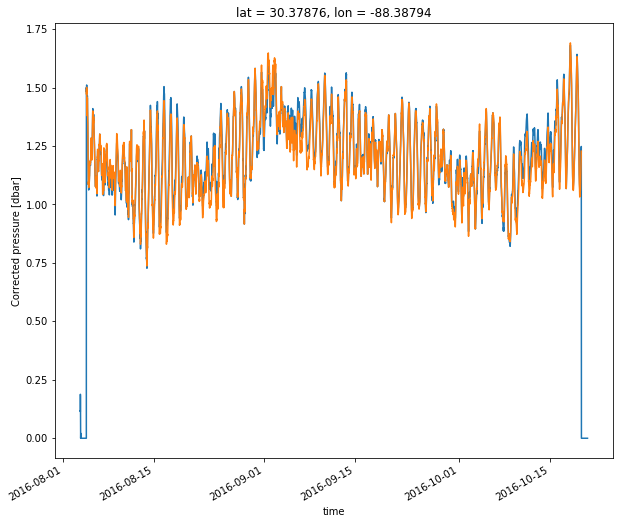

In [6]:
plt.figure(figsize=(10,8))
RAW['Pressure'].plot()
VEL['P_1ac'].plot()
plt.show()